In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dspca as dspca

from sklearn.model_selection import train_test_split

In [2]:
PATH_DATA = "../data/mnist/mnist.parquet"

N_COMPONENTS = 3
SPARSITY_LEVELS = [70, 30, 20]  # Nested sparsity
MAX_SENSORS = 100  # Maximum number of sensors to use
N_SAMPLES = 1000  # Set to None to use full dataset

In [3]:
data = pd.read_parquet(PATH_DATA)

X = data.drop("class", axis=1)
y = data["class"]

In [4]:
np.max(X), np.min(X)

(np.int64(255), np.int64(0))

In [5]:
y = y.astype(int)
X = X.astype(np.float64)

X = X / np.max(X)

In [6]:
X_sample, _, y_sample, _ = train_test_split(
    X, y,
    train_size=N_SAMPLES,
    random_state=42,
    stratify=y
)

In [7]:
X_sample.shape

(1000, 784)

In [8]:
dspca = dspca.DSPCA(n_components=N_COMPONENTS, sparsity_levels=SPARSITY_LEVELS, max_sensors=MAX_SENSORS)

In [9]:
%%time
dspca.fit(X_sample)

CPU times: user 18.8 s, sys: 448 ms, total: 19.3 s
Wall time: 19 s


DSPCA(n_components=3, sparsity_levels=[70, 30, 20])

In [10]:
dspca.__str__()

'DSPCA(n_components=3, fitted) \nSparsity per component: [70, 30, 20] \nExplained variance: [3.097952782842735, 1.8279715227704723, 1.0530707687240233] \nExplained variance ratio: [0.05891640558166786, 0.03476409073235101, 0.02002714336382217]'

In [11]:
X_transformed = dspca.transform(X_sample)

In [12]:
X_transformed.shape

(1000, 3)

In [13]:
X_transformed[:20, 0]

array([ 0.44818209,  1.85322448,  2.85663056, -2.20642978,  0.8451745 ,
        0.40931561,  3.46617193,  0.0764652 , -0.87076182, -2.20458298,
       -0.7915991 , -1.28422731, -0.88582107, -1.0183118 , -1.49378089,
       -1.27568068, -0.38502899,  0.56242325, -2.49124362,  0.46715651])

In [14]:
for component in dspca.components_:
    print(len(component))

70
30
20


In [15]:
dspca.weights_

[array([0.16670005, 0.18834965, 0.17755109, 0.18986789, 0.18344593,
        0.14858455, 0.1793791 , 0.15576924, 0.13361234, 0.13044877,
        0.12231523, 0.13179482, 0.1536497 , 0.15818994, 0.13699913,
        0.15124441, 0.14930373, 0.14608943, 0.15997023, 0.12934935,
        0.12798816, 0.120909  , 0.14663182, 0.145041  , 0.10469594,
        0.13727632, 0.11500257, 0.1208895 , 0.12812514, 0.1153633 ,
        0.10216018, 0.13138865, 0.13309343, 0.10353918, 0.11040484,
        0.11198378, 0.11363389, 0.11543319, 0.09549144, 0.10291762,
        0.1063626 , 0.10762881, 0.10096671, 0.10488096, 0.10524614,
        0.10607972, 0.09772479, 0.09019298, 0.09084351, 0.08966087,
        0.08432714, 0.08575668, 0.08590075, 0.08366367, 0.07730986,
        0.0835624 , 0.08950734, 0.07798127, 0.08391974, 0.08330537,
        0.08059963, 0.07636261, 0.07266342, 0.07875049, 0.07561708,
        0.07532806, 0.07311422, 0.07139819, 0.07071052, 0.07013347]),
 array([0.22240342, 0.25128912, 0.26455153, 0.

In [28]:
features = np.zeros((len(SPARSITY_LEVELS), 784))

In [37]:
for n in range(len(SPARSITY_LEVELS)):
    for idx, component in enumerate(dspca.components_[n]):
        features[n, component] = np.square(dspca.weights_[n][idx])

In [39]:
features = features.reshape(features.shape[0], 28, 28)

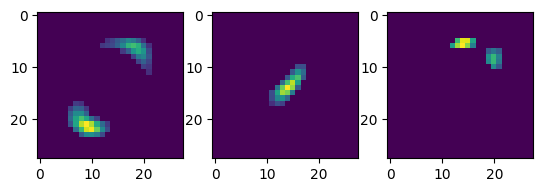

In [42]:
fig, ax = plt.subplots(1, 3)
for i in range(3):
    ax[i].imshow(features[i])